<a href="https://colab.research.google.com/github/mwakitrevor146-prog/machine-learning-projects/blob/main/forward_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas scikit-learn
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
# Sample dataset: Study hours, previous exam scores, and pass/fail labels
data = {
    'StudyHours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'PrevExamScore': [30, 40, 45, 50, 60, 65, 70, 75, 80, 85],
    'Pass': [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]  # 0 = Fail, 1 = Pass
}

df = pd.DataFrame(data)

# Features and target variable
X = df[['StudyHours', 'PrevExamScore']]
y = df['Pass']
def forward_selection(X, y):
    remaining_features = set(X.columns)
    selected_features = []
    current_score = 0.0
    best_score = 0.0

    while remaining_features:
        scores_with_candidates = []

        # Loop through remaining features
        for feature in remaining_features:
            features_to_test = selected_features + [feature]
            X_train, X_test, y_train, y_test = train_test_split(X[features_to_test], y, test_size=0.2, random_state=42)

            # Train the model
            model = LinearRegression()
            model.fit(X_train, y_train)

            # Make predictions and calculate R-squared
            y_pred = model.predict(X_test)
            score = r2_score(y_test, y_pred)

            # Record the score with the current feature
            scores_with_candidates.append((score, feature))

        # Sort candidates by score (highest score first)
        scores_with_candidates.sort(reverse=True)
        best_score, best_feature = scores_with_candidates[0]

        # If adding the feature improves the score, add it to the model
        if current_score < best_score:
            remaining_features.remove(best_feature)
            selected_features.append(best_feature)
            current_score = best_score
        else:
            break

    return selected_features

# Run forward selection
best_features = forward_selection(X, y)
print("Selected features using Forward Selection:", best_features)

Selected features using Forward Selection: ['PrevExamScore']


/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


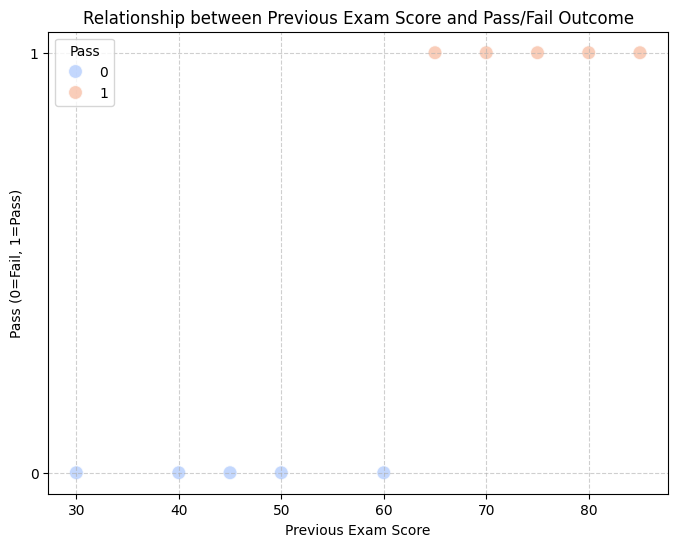

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PrevExamScore', y='Pass', data=df, hue='Pass', palette='coolwarm', s=100, alpha=0.7)
sns.regplot(x='PrevExamScore', y='Pass', data=df, logistic=True, color='blue', scatter=False, line_kws={'linestyle': '--'})
plt.title('Relationship between Previous Exam Score and Pass/Fail Outcome')
plt.xlabel('Previous Exam Score')
plt.ylabel('Pass (0=Fail, 1=Pass)')
plt.yticks([0, 1])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()